# Week 5: Support Vector Machines and Feature Scaling

This notebook applies Support Vector Machines (SVMs) to the chronic disease datasets used throughout the capstone project. The goal is to evaluate whether SVM models can improve classification performance compared to previous models, especially when the data includes class imbalance or complex relationships between features.

SVMs classify data by finding a decision boundary, or hyperplane, that separates classes. Unlike logistic regression, which estimates probabilities, SVMs focus on maximizing the margin between classes. This makes SVMs useful when the separation between groups is important.

This notebook also examines feature scaling, the kernel trick, and the regularization parameter C. These concepts are important because SVMs are sensitive to feature scale and can use different kernels to create nonlinear decision boundaries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## Step 1: Load the Datasets

The same two datasets from the previous weeks are used here so that the SVM results can be compared with earlier models. The diabetes dataset is a multi-class classification problem, while the Alzheimer's dataset may require selecting or confirming the correct target variable before modeling.

In [2]:
diabetes_df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
alzheimers_df = pd.read_csv("alzheimers_disease_data.csv")

print("Diabetes dataset shape:", diabetes_df.shape)
print("Alzheimer's dataset shape:", alzheimers_df.shape)

Diabetes dataset shape: (253680, 22)
Alzheimer's dataset shape: (2149, 35)


## Step 2: Inspect Dataset Columns and Target Variables

Before training SVM models, the columns in each dataset need to be reviewed. This helps confirm which variable should be used as the prediction target and which variables should be used as features.

For the diabetes dataset, the target variable is expected to be `Diabetes_012`, which represents diabetes classification status. For the Alzheimer's dataset, the target variable needs to be confirmed from the available columns.

In [4]:
print("Diabetes columns:")
print(diabetes_df.columns.tolist())

print("\nAlzheimer's columns:")
print(alzheimers_df.columns.tolist())

Diabetes columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Alzheimer's columns:
['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']


In [5]:
# Preview the first few rows of each dataset
display(diabetes_df.head())
display(alzheimers_df.head())

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## Step 3: Define Features and Target Variables

For the diabetes dataset, the target variable is `Diabetes_012`. This is a multi-class classification target where the model predicts diabetes status.

For the Alzheimer's dataset, the target variable is `Diagnosis`. The columns `PatientID` and `DoctorInCharge` are removed from the feature set because they are identifiers or administrative fields rather than useful clinical predictors.

This step separates each dataset into independent variables `X` and target variables `y`.

In [6]:
# Define features and target for Diabetes dataset
X_diabetes = diabetes_df.drop("Diabetes_012", axis=1)
y_diabetes = diabetes_df["Diabetes_012"]

# Define features and target for Alzheimer's dataset
X_alzheimers = alzheimers_df.drop(["Diagnosis", "PatientID", "DoctorInCharge"], axis=1)
y_alzheimers = alzheimers_df["Diagnosis"]

# Confirm shapes
print("Diabetes features shape:", X_diabetes.shape)
print("Diabetes target shape:", y_diabetes.shape)

print("\nAlzheimer's features shape:", X_alzheimers.shape)
print("Alzheimer's target shape:", y_alzheimers.shape)

Diabetes features shape: (253680, 21)
Diabetes target shape: (253680,)

Alzheimer's features shape: (2149, 32)
Alzheimer's target shape: (2149,)


## Step 4: Check Target Class Balance

Before training SVM models, it is important to check the distribution of the target classes. Class imbalance can make accuracy misleading because a model may perform well overall while still failing to predict minority classes.

This was already an issue in the diabetes dataset during logistic regression, where the model achieved high accuracy but struggled with the smaller diabetes categories. For SVMs, class balance should be checked again so that the evaluation can focus on both accuracy and macro F1-score.

In [7]:
# Check target class distributions
print("Diabetes target distribution:")
print(y_diabetes.value_counts().sort_index())

print("\nDiabetes target distribution (%):")
print((y_diabetes.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nAlzheimer's target distribution:")
print(y_alzheimers.value_counts().sort_index())

print("\nAlzheimer's target distribution (%):")
print((y_alzheimers.value_counts(normalize=True).sort_index() * 100).round(2))

Diabetes target distribution:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Diabetes target distribution (%):
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: proportion, dtype: float64

Alzheimer's target distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Alzheimer's target distribution (%):
Diagnosis
0    64.63
1    35.37
Name: proportion, dtype: float64


## Step 5: Train/Test Split

The datasets are split into training and testing sets so that the SVM models can be evaluated on data they did not see during training.

A stratified split is used because both datasets have class imbalance. Stratification preserves the original class proportions in both the training and testing sets.

In [8]:
# Split Diabetes dataset
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

# Split Alzheimer's dataset
X_train_alzheimers, X_test_alzheimers, y_train_alzheimers, y_test_alzheimers = train_test_split(
    X_alzheimers,
    y_alzheimers,
    test_size=0.2,
    random_state=42,
    stratify=y_alzheimers
)

# Confirm split sizes
print("Diabetes training features:", X_train_diabetes.shape)
print("Diabetes testing features:", X_test_diabetes.shape)

print("\nAlzheimer's training features:", X_train_alzheimers.shape)
print("Alzheimer's testing features:", X_test_alzheimers.shape)

Diabetes training features: (202944, 21)
Diabetes testing features: (50736, 21)

Alzheimer's training features: (1719, 32)
Alzheimer's testing features: (430, 32)


## Step 6: Feature Scaling

Feature scaling is especially important for Support Vector Machines because SVMs depend on distances between points and the decision boundary. If one feature has a much larger numeric range than another, it can dominate the margin calculation.

For example, BMI or blood pressure values may have larger ranges than binary variables such as smoking status or physical activity. Standardizing the data gives each feature a mean of 0 and a standard deviation of 1, making the SVM comparison across features more balanced.

The scaler is fit only on the training data and then applied to the testing data. This avoids data leakage.

In [9]:
# Create separate scalers for each dataset
diabetes_scaler = StandardScaler()
alzheimers_scaler = StandardScaler()

# Fit scaler on training data and transform both training and testing data
X_train_diabetes_scaled = diabetes_scaler.fit_transform(X_train_diabetes)
X_test_diabetes_scaled = diabetes_scaler.transform(X_test_diabetes)

X_train_alzheimers_scaled = alzheimers_scaler.fit_transform(X_train_alzheimers)
X_test_alzheimers_scaled = alzheimers_scaler.transform(X_test_alzheimers)

print("Diabetes scaled training shape:", X_train_diabetes_scaled.shape)
print("Diabetes scaled testing shape:", X_test_diabetes_scaled.shape)

print("\nAlzheimer's scaled training shape:", X_train_alzheimers_scaled.shape)
print("Alzheimer's scaled testing shape:", X_test_alzheimers_scaled.shape)

Diabetes scaled training shape: (202944, 21)
Diabetes scaled testing shape: (50736, 21)

Alzheimer's scaled training shape: (1719, 32)
Alzheimer's scaled testing shape: (430, 32)


## Step 7: Train Linear SVM Models

The first SVM model tested is a linear SVM. A linear SVM creates a straight decision boundary between classes. This is similar to logistic regression in that both models create linear separators, but the SVM focuses on maximizing the margin between classes rather than estimating probabilities.

Because the diabetes dataset is very imbalanced, `class_weight="balanced"` is used. This gives more weight to the minority classes during training so the model does not simply favor the majority class. The same setting is also used for the Alzheimer's dataset for consistency.

In [10]:
# Train Linear SVM model for Diabetes dataset
linear_svm_diabetes = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=10000
)

linear_svm_diabetes.fit(X_train_diabetes_scaled, y_train_diabetes)

# Predict on Diabetes test set
y_pred_diabetes_linear_svm = linear_svm_diabetes.predict(X_test_diabetes_scaled)

In [11]:
# Train Linear SVM model for Alzheimer's dataset
linear_svm_alzheimers = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=10000
)

linear_svm_alzheimers.fit(X_train_alzheimers_scaled, y_train_alzheimers)

# Predict on Alzheimer's test set
y_pred_alzheimers_linear_svm = linear_svm_alzheimers.predict(X_test_alzheimers_scaled)

## Step 8: Evaluate Linear SVM Models

The models are evaluated using accuracy, macro F1-score, confusion matrices, and classification reports.

Accuracy measures the overall percentage of correct predictions, but it can be misleading when the target classes are imbalanced. Macro F1-score is especially useful here because it gives equal weight to each class, including minority classes.

In [12]:
# Evaluate Diabetes Linear SVM
diabetes_linear_svm_accuracy = accuracy_score(y_test_diabetes, y_pred_diabetes_linear_svm)
diabetes_linear_svm_macro_f1 = f1_score(y_test_diabetes, y_pred_diabetes_linear_svm, average="macro")

print("Diabetes Linear SVM Accuracy:", diabetes_linear_svm_accuracy)
print("Diabetes Linear SVM Macro F1:", diabetes_linear_svm_macro_f1)

print("\nDiabetes Linear SVM Confusion Matrix:")
print(confusion_matrix(y_test_diabetes, y_pred_diabetes_linear_svm))

print("\nDiabetes Linear SVM Classification Report:")
print(classification_report(y_test_diabetes, y_pred_diabetes_linear_svm))

Diabetes Linear SVM Accuracy: 0.818531220435194
Diabetes Linear SVM Macro F1: 0.44669974520410854

Diabetes Linear SVM Confusion Matrix:
[[38158    21  4562]
 [  622     2   302]
 [ 3693     7  3369]]

Diabetes Linear SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90     42741
         1.0       0.07      0.00      0.00       926
         2.0       0.41      0.48      0.44      7069

    accuracy                           0.82     50736
   macro avg       0.46      0.46      0.45     50736
weighted avg       0.82      0.82      0.82     50736



### Diabetes Linear SVM Interpretation

The Linear SVM achieved an accuracy of approximately 81.85% and a macro F1-score of approximately 0.45. Compared to the previous logistic regression model, the SVM had lower overall accuracy but a better macro F1-score.

This is important because the diabetes dataset is highly imbalanced, with most observations belonging to class 0. Accuracy alone can make a model look strong even when it performs poorly on minority classes. The Linear SVM still struggled to classify class 1, but it improved the balance of performance across classes compared to logistic regression.

The confusion matrix shows that the model classified class 0 well and performed moderately on class 2, but it almost never correctly predicted class 1. This suggests that class 1 may be difficult to separate from the other diabetes categories using the current features.

In [13]:
# Evaluate Alzheimer's Linear SVM
alzheimers_linear_svm_accuracy = accuracy_score(y_test_alzheimers, y_pred_alzheimers_linear_svm)
alzheimers_linear_svm_macro_f1 = f1_score(y_test_alzheimers, y_pred_alzheimers_linear_svm, average="macro")

print("Alzheimer's Linear SVM Accuracy:", alzheimers_linear_svm_accuracy)
print("Alzheimer's Linear SVM Macro F1:", alzheimers_linear_svm_macro_f1)

print("\nAlzheimer's Linear SVM Confusion Matrix:")
print(confusion_matrix(y_test_alzheimers, y_pred_alzheimers_linear_svm))

print("\nAlzheimer's Linear SVM Classification Report:")
print(classification_report(y_test_alzheimers, y_pred_alzheimers_linear_svm))

Alzheimer's Linear SVM Accuracy: 0.8093023255813954
Alzheimer's Linear SVM Macro F1: 0.8009663799137483

Alzheimer's Linear SVM Confusion Matrix:
[[218  60]
 [ 22 130]]

Alzheimer's Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       278
           1       0.68      0.86      0.76       152

    accuracy                           0.81       430
   macro avg       0.80      0.82      0.80       430
weighted avg       0.83      0.81      0.81       430



### Alzheimer's Linear SVM Interpretation

The Linear SVM performed well on the Alzheimer's dataset, with an accuracy of approximately 80.93% and a macro F1-score of approximately 0.80. Unlike the diabetes dataset, the Alzheimer's target variable is less severely imbalanced, so the model was able to classify both groups more effectively.

The confusion matrix shows that the model correctly identified 218 non-diagnosis cases and 130 diagnosis cases. It had stronger recall for class 1 than class 0, meaning it detected a high percentage of diagnosed Alzheimer's cases. This is useful in a healthcare setting because failing to identify a disease case may be more harmful than incorrectly flagging a possible case.

Overall, the Linear SVM appears to be a reasonable model for the Alzheimer's dataset. Its balanced macro F1-score suggests that it performs well across both classes instead of only favoring the majority class.

## Step 9: Compare Linear SVM Results Across Datasets

The Linear SVM model performed differently across the two datasets. This comparison helps show how dataset size, class imbalance, and target structure affect model performance.

The diabetes dataset is much larger but highly imbalanced, especially for class 1. The Alzheimer's dataset is smaller but has a more balanced binary target. Because of this, the Linear SVM achieved stronger balanced performance on the Alzheimer's dataset.

In [14]:
# Create comparison table for Linear SVM results
linear_svm_results = pd.DataFrame({
    "Dataset": ["Diabetes", "Alzheimer's"],
    "Model": ["Linear SVM", "Linear SVM"],
    "Accuracy": [diabetes_linear_svm_accuracy, alzheimers_linear_svm_accuracy],
    "Macro F1": [diabetes_linear_svm_macro_f1, alzheimers_linear_svm_macro_f1]
})

linear_svm_results

,Dataset,Model,Accuracy,Macro F1
0,Diabetes,Linear SVM,0.818531,0.446700
1,Alzheimer's,Linear SVM,0.809302,0.800966


### Linear SVM Comparison Summary

The Linear SVM performed better on the Alzheimer's dataset than on the diabetes dataset. The Alzheimer's model had both strong accuracy and strong macro F1-score, which suggests balanced classification performance.

For the diabetes dataset, the accuracy was still fairly high, but the macro F1-score was much lower. This happened because the model struggled with the minority class, especially class 1. However, compared to the previous logistic regression model, the Linear SVM improved macro F1 while sacrificing some accuracy. This shows why macro F1 is more informative than accuracy for imbalanced health classification problems.

## Step 10: Kernel Trick and Nonlinear SVM Models

The kernel trick allows an SVM to create nonlinear decision boundaries without manually creating higher-dimensional features. A linear kernel creates a straight decision boundary, while nonlinear kernels such as polynomial or radial basis function (RBF) kernels can capture more complex relationships.

Because the full diabetes dataset is very large, nonlinear SVM models may be slow to train. For this reason, kernel-based SVMs are tested on a smaller stratified sample of the diabetes dataset. The Alzheimer's dataset is smaller, so nonlinear SVM models can be tested more directly.

In [16]:
# Create smaller stratified sample for diabetes nonlinear SVM testing
diabetes_sample = diabetes_df.groupby("Diabetes_012", group_keys=False).sample(
    frac=0.10,
    random_state=42
)

# Reset index to keep the sampled dataframe clean
diabetes_sample = diabetes_sample.reset_index(drop=True)

# Separate features and target
X_diabetes_sample = diabetes_sample.drop(columns=["Diabetes_012"])
y_diabetes_sample = diabetes_sample["Diabetes_012"]

print("Sampled diabetes dataset shape:", diabetes_sample.shape)

print("\nSampled diabetes target distribution:")
print(y_diabetes_sample.value_counts().sort_index())

print("\nSampled diabetes target distribution (%):")
print((y_diabetes_sample.value_counts(normalize=True).sort_index() * 100).round(2))

Sampled diabetes dataset shape: (25368, 22)

Sampled diabetes target distribution:
Diabetes_012
0.0    21370
1.0      463
2.0     3535
Name: count, dtype: int64

Sampled diabetes target distribution (%):
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: proportion, dtype: float64


### Preparing the Sampled Diabetes Data for Kernel SVMs

Because nonlinear SVM models can be computationally expensive on large datasets, a 10% stratified sample of the diabetes dataset is used for kernel testing. The class proportions are preserved, so the sample still reflects the imbalance of the original dataset.

The sampled data is split into training and testing sets and then standardized using `StandardScaler`.

In [17]:
# Split sampled Diabetes dataset
X_train_diabetes_sample, X_test_diabetes_sample, y_train_diabetes_sample, y_test_diabetes_sample = train_test_split(
    X_diabetes_sample,
    y_diabetes_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes_sample
)

# Scale sampled Diabetes dataset
diabetes_sample_scaler = StandardScaler()

X_train_diabetes_sample_scaled = diabetes_sample_scaler.fit_transform(X_train_diabetes_sample)
X_test_diabetes_sample_scaled = diabetes_sample_scaler.transform(X_test_diabetes_sample)

print("Sampled Diabetes training features:", X_train_diabetes_sample_scaled.shape)
print("Sampled Diabetes testing features:", X_test_diabetes_sample_scaled.shape)

Sampled Diabetes training features: (20294, 21)
Sampled Diabetes testing features: (5074, 21)


## Step 11: RBF Kernel SVM on Sampled Diabetes Data

The RBF kernel is a nonlinear SVM kernel that can create curved decision boundaries. This is useful when the classes cannot be separated well with a straight hyperplane.

For the diabetes dataset, the RBF model is tested on the 10% stratified sample instead of the full dataset because nonlinear SVM models are more computationally expensive than linear SVMs.

The model also uses `class_weight="balanced"` because the diabetes target remains highly imbalanced even after sampling.

In [18]:
# Train RBF Kernel SVM on sampled Diabetes data
rbf_svm_diabetes = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

rbf_svm_diabetes.fit(X_train_diabetes_sample_scaled, y_train_diabetes_sample)

# Predict on sampled Diabetes test set
y_pred_diabetes_rbf_svm = rbf_svm_diabetes.predict(X_test_diabetes_sample_scaled)

In [19]:
# Evaluate Diabetes RBF SVM
diabetes_rbf_svm_accuracy = accuracy_score(y_test_diabetes_sample, y_pred_diabetes_rbf_svm)
diabetes_rbf_svm_macro_f1 = f1_score(y_test_diabetes_sample, y_pred_diabetes_rbf_svm, average="macro")

print("Diabetes RBF SVM Accuracy:", diabetes_rbf_svm_accuracy)
print("Diabetes RBF SVM Macro F1:", diabetes_rbf_svm_macro_f1)

print("\nDiabetes RBF SVM Confusion Matrix:")
print(confusion_matrix(y_test_diabetes_sample, y_pred_diabetes_rbf_svm))

print("\nDiabetes RBF SVM Classification Report:")
print(classification_report(y_test_diabetes_sample, y_pred_diabetes_rbf_svm))

Diabetes RBF SVM Accuracy: 0.6487977926685061
Diabetes RBF SVM Macro F1: 0.4119738043740351

Diabetes RBF SVM Confusion Matrix:
[[2842  478  954]
 [  34   19   40]
 [ 153  123  431]]

Diabetes RBF SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.66      0.78      4274
         1.0       0.03      0.20      0.05        93
         2.0       0.30      0.61      0.40       707

    accuracy                           0.65      5074
   macro avg       0.42      0.49      0.41      5074
weighted avg       0.83      0.65      0.71      5074



### Diabetes RBF SVM Interpretation

The RBF SVM achieved an accuracy of approximately 64.88% and a macro F1-score of approximately 0.41 on the sampled diabetes dataset. This was weaker than the Linear SVM, which had higher accuracy and a higher macro F1-score.

The RBF model predicted the minority classes more often than the logistic regression and linear SVM models, but this came at a major cost to class 0 performance. The confusion matrix shows that many class 0 cases were incorrectly classified as class 1 or class 2. This lowered the overall accuracy substantially.

The model did improve recall for class 1 compared to previous models, but the precision for class 1 was extremely low. This means the model identified more possible class 1 cases, but most of those predictions were incorrect. In a healthcare setting, this could create too many false positives.

Overall, the RBF kernel did not clearly improve the diabetes classification problem. The result suggests that the main challenge may be class imbalance and weak class separation rather than simply needing a nonlinear decision boundary.

## Step 12: RBF Kernel SVM on Alzheimer's Dataset

The Alzheimer's dataset is smaller and less imbalanced than the diabetes dataset, making it more practical for testing nonlinear SVM models on the full dataset.

The RBF kernel is tested to see whether a nonlinear decision boundary improves classification compared to the Linear SVM.

In [20]:
# Train RBF Kernel SVM on Alzheimer's data
rbf_svm_alzheimers = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

rbf_svm_alzheimers.fit(X_train_alzheimers_scaled, y_train_alzheimers)

# Predict on Alzheimer's test set
y_pred_alzheimers_rbf_svm = rbf_svm_alzheimers.predict(X_test_alzheimers_scaled)

In [21]:
# Evaluate Alzheimer's RBF SVM
alzheimers_rbf_svm_accuracy = accuracy_score(y_test_alzheimers, y_pred_alzheimers_rbf_svm)
alzheimers_rbf_svm_macro_f1 = f1_score(y_test_alzheimers, y_pred_alzheimers_rbf_svm, average="macro")

print("Alzheimer's RBF SVM Accuracy:", alzheimers_rbf_svm_accuracy)
print("Alzheimer's RBF SVM Macro F1:", alzheimers_rbf_svm_macro_f1)

print("\nAlzheimer's RBF SVM Confusion Matrix:")
print(confusion_matrix(y_test_alzheimers, y_pred_alzheimers_rbf_svm))

print("\nAlzheimer's RBF SVM Classification Report:")
print(classification_report(y_test_alzheimers, y_pred_alzheimers_rbf_svm))

Alzheimer's RBF SVM Accuracy: 0.8418604651162791
Alzheimer's RBF SVM Macro F1: 0.8316288925741662

Alzheimer's RBF SVM Confusion Matrix:
[[234  44]
 [ 24 128]]

Alzheimer's RBF SVM Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       278
           1       0.74      0.84      0.79       152

    accuracy                           0.84       430
   macro avg       0.83      0.84      0.83       430
weighted avg       0.85      0.84      0.84       430



### Alzheimer's RBF SVM Interpretation

The RBF SVM achieved an accuracy of approximately 84.19% and a macro F1-score of approximately 0.83. This was better than the Linear SVM model, which had an accuracy of approximately 80.93% and a macro F1-score of approximately 0.80.

This suggests that the Alzheimer's dataset may contain nonlinear relationships that a straight decision boundary does not fully capture. The RBF kernel improved performance by allowing the SVM to create a more flexible decision boundary.

The confusion matrix shows that the RBF SVM correctly classified 234 non-diagnosis cases and 128 diagnosis cases. Compared to the Linear SVM, it reduced false positives while maintaining strong recall for diagnosed Alzheimer's cases.

Overall, the RBF kernel improved the Alzheimer's classification model, making it the strongest SVM model tested so far for this dataset.

In [22]:
# Create comparison table for SVM models
svm_results = pd.DataFrame({
    "Dataset": [
        "Diabetes",
        "Diabetes",
        "Alzheimer's",
        "Alzheimer's"
    ],
    "Model": [
        "Linear SVM",
        "RBF SVM (10% sample)",
        "Linear SVM",
        "RBF SVM"
    ],
    "Accuracy": [
        diabetes_linear_svm_accuracy,
        diabetes_rbf_svm_accuracy,
        alzheimers_linear_svm_accuracy,
        alzheimers_rbf_svm_accuracy
    ],
    "Macro F1": [
        diabetes_linear_svm_macro_f1,
        diabetes_rbf_svm_macro_f1,
        alzheimers_linear_svm_macro_f1,
        alzheimers_rbf_svm_macro_f1
    ]
})

svm_results

,Dataset,Model,Accuracy,Macro F1
0,Diabetes,Linear SVM,0.818531,0.446700
1,Diabetes,RBF SVM (10% sample),0.648798,0.411974
2,Alzheimer's,Linear SVM,0.809302,0.800966
3,Alzheimer's,RBF SVM,0.841860,0.831629


### SVM Model Comparison Summary

The SVM results differed across the two datasets. For the diabetes dataset, the Linear SVM performed better than the RBF SVM. The RBF model predicted minority classes more often, but it created too many false positives and reduced overall performance. This suggests that the diabetes problem is affected more by class imbalance and weak separation between classes than by the need for a nonlinear kernel.

For the Alzheimer's dataset, the RBF SVM outperformed the Linear SVM. This suggests that the Alzheimer's features may have nonlinear relationships with diagnosis status. The RBF kernel helped capture these relationships and improved both accuracy and macro F1-score.

Overall, the kernel trick was more useful for the Alzheimer's dataset than for the diabetes dataset.

## Step 14: SVM Regularization Using C

SVM models use the regularization parameter `C` to control the trade-off between maximizing the margin and correctly classifying training points.

A smaller value of `C` allows a wider margin and permits more classification errors. This can help prevent overfitting. A larger value of `C` tries harder to classify training points correctly, but it can create a narrower margin and may overfit the training data.

In this section, different values of `C` are tested on the Alzheimer's RBF SVM model to see how regularization affects accuracy and macro F1-score.

In [23]:
# Test different C values for Alzheimer's RBF SVM
c_values = [0.1, 1, 10, 100]

alzheimers_c_results = []

for c in c_values:
    model = SVC(
        kernel="rbf",
        C=c,
        class_weight="balanced",
        random_state=42
    )
    
    model.fit(X_train_alzheimers_scaled, y_train_alzheimers)
    y_pred = model.predict(X_test_alzheimers_scaled)
    
    accuracy = accuracy_score(y_test_alzheimers, y_pred)
    macro_f1 = f1_score(y_test_alzheimers, y_pred, average="macro")
    
    alzheimers_c_results.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

alzheimers_c_results_df = pd.DataFrame(alzheimers_c_results)
alzheimers_c_results_df

,C,Accuracy,Macro F1
0,0.1,0.795349,0.787626
1,1.0,0.841860,0.831629
2,10.0,0.818605,0.797776
3,100.0,0.816279,0.796190


### Alzheimer's C Regularization Interpretation

The best Alzheimer's RBF SVM result occurred when `C = 1.0`, with an accuracy of approximately 84.19% and a macro F1-score of approximately 0.83.

When `C = 0.1`, performance was lower. This suggests that the model may have allowed too many classification errors in exchange for a wider margin, causing slight underfitting.

When `C = 10` and `C = 100`, performance also decreased. These larger values of `C` make the SVM try harder to classify the training data correctly, but in this case they did not generalize better to the test data.

Overall, the default regularization level of `C = 1.0` provided the best balance between margin size and classification accuracy for the Alzheimer's dataset.

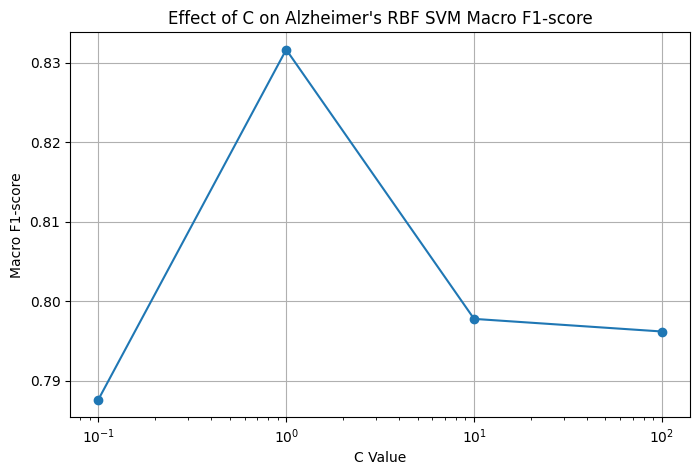

In [24]:
# Plot C values against Macro F1-score for Alzheimer's RBF SVM
plt.figure(figsize=(8, 5))
plt.plot(alzheimers_c_results_df["C"], alzheimers_c_results_df["Macro F1"], marker="o")
plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Macro F1-score")
plt.title("Effect of C on Alzheimer's RBF SVM Macro F1-score")
plt.grid(True)
plt.show()

### C Value Plot Interpretation

The plot shows that the Alzheimer's RBF SVM performed best at `C = 1.0`. When `C` was too small, the model likely allowed too many classification errors in exchange for a wider margin. When `C` was too large, the model tried harder to fit the training data but did not improve test performance.

This supports the idea that SVM regularization requires balance. The best model is not always the one that fits the training data most aggressively. In this case, the default value of `C = 1.0` provided the strongest macro F1-score and the best balance between margin size and classification performance.

## Step 15: Regularization with Linear SVM on the Diabetes Dataset

The diabetes dataset is much larger and more imbalanced than the Alzheimer's dataset, so regularization is tested using `LinearSVC` instead of nonlinear SVM models.

This section tests different values of `C` to see whether changing the regularization strength improves the diabetes Linear SVM performance. Since the diabetes dataset is highly imbalanced, macro F1-score remains the most important metric.

In [25]:
# Test different C values for Diabetes Linear SVM
c_values = [0.01, 0.1, 1, 10]

diabetes_c_results = []

for c in c_values:
    model = LinearSVC(
        C=c,
        class_weight="balanced",
        random_state=42,
        max_iter=10000
    )
    
    model.fit(X_train_diabetes_scaled, y_train_diabetes)
    y_pred = model.predict(X_test_diabetes_scaled)
    
    accuracy = accuracy_score(y_test_diabetes, y_pred)
    macro_f1 = f1_score(y_test_diabetes, y_pred, average="macro")
    
    diabetes_c_results.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

diabetes_c_results_df = pd.DataFrame(diabetes_c_results)
diabetes_c_results_df

,C,Accuracy,Macro F1
0,0.01,0.818551,0.446737
1,0.10,0.818551,0.446714
2,1.00,0.818531,0.446700
3,10.00,0.818531,0.446700


### Diabetes C Regularization Interpretation

Changing the value of `C` did not meaningfully change the Linear SVM performance on the diabetes dataset. The accuracy stayed around 81.85%, and the macro F1-score stayed around 0.447 for all tested values.

The best value was technically `C = 0.01`, but the difference compared to the other values was extremely small. This suggests that regularization strength was not the main limitation for the diabetes model.

Instead, the larger issue appears to be the structure of the dataset itself. The diabetes target is highly imbalanced, especially for class 1, and the available features may not separate the three diabetes categories clearly enough. Even with balanced class weights and different `C` values, the model continued to struggle with the minority class.

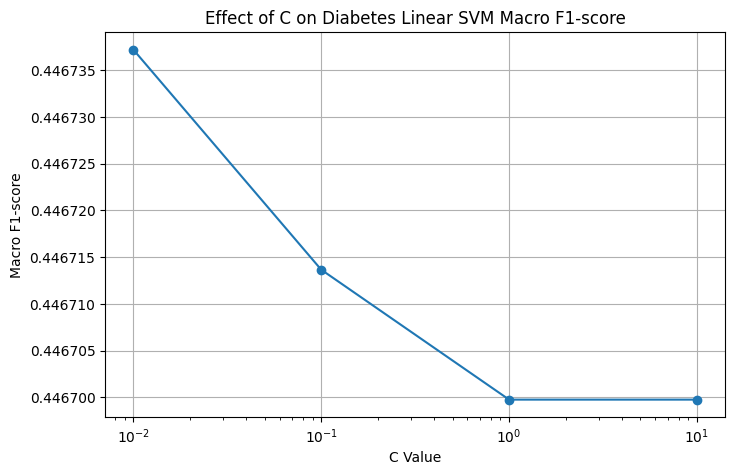

In [26]:
# Plot C values against Macro F1-score for Diabetes Linear SVM
plt.figure(figsize=(8, 5))
plt.plot(diabetes_c_results_df["C"], diabetes_c_results_df["Macro F1"], marker="o")
plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Macro F1-score")
plt.title("Effect of C on Diabetes Linear SVM Macro F1-score")
plt.grid(True)
plt.show()

### Diabetes C Value Plot Interpretation

The plot shows that the diabetes Linear SVM macro F1-score changed very little across different values of `C`. Although the line appears to decline, the actual difference between the highest and lowest macro F1-score is extremely small.

This suggests that changing the regularization strength did not meaningfully improve the diabetes model. The best value was technically `C = 0.01`, but the improvement was too small to be practically important.

For this dataset, the main issue appears to be class imbalance and difficulty separating the three diabetes categories, especially class 1. Regularization alone was not enough to solve that problem.

## Final Week 5 Conclusion

This notebook applied Support Vector Machine models to both the diabetes and Alzheimer's datasets. The main concepts tested were feature scaling, linear SVM classification, the kernel trick, and SVM regularization using the parameter `C`.

Feature scaling was necessary because SVMs depend on distances and margins. Without scaling, features with larger numeric ranges could dominate the decision boundary.

For the diabetes dataset, the Linear SVM achieved fairly high accuracy but only moderate macro F1-score. This was because the dataset was highly imbalanced, with class 0 making up most of the observations and class 1 making up less than 2%. The model continued to struggle with class 1 even after using balanced class weights. The RBF kernel did not improve the diabetes model; it predicted minority classes more often but created too many false positives.

For the Alzheimer's dataset, the SVM models performed much better. The Linear SVM produced strong accuracy and macro F1-score, and the RBF SVM improved performance further. This suggests that nonlinear relationships may exist in the Alzheimer's dataset and that the kernel trick helped capture those relationships.

Regularization had different effects across the two datasets. For Alzheimer's, `C = 1.0` gave the best RBF SVM performance. For diabetes, changing `C` barely affected the Linear SVM results. This suggests that the diabetes model was limited more by class imbalance and class overlap than by regularization settings.

Overall, SVMs were more effective for the Alzheimer's dataset than for the diabetes dataset. The results show that model performance depends heavily on dataset structure, class balance, and whether the decision boundary needs to be linear or nonlinear.

In [27]:
# Final SVM results summary
final_svm_summary = pd.DataFrame({
    "Dataset": [
        "Diabetes",
        "Diabetes",
        "Alzheimer's",
        "Alzheimer's"
    ],
    "Best/Tested Model": [
        "Linear SVM",
        "RBF SVM (10% sample)",
        "Linear SVM",
        "RBF SVM"
    ],
    "Accuracy": [
        diabetes_linear_svm_accuracy,
        diabetes_rbf_svm_accuracy,
        alzheimers_linear_svm_accuracy,
        alzheimers_rbf_svm_accuracy
    ],
    "Macro F1": [
        diabetes_linear_svm_macro_f1,
        diabetes_rbf_svm_macro_f1,
        alzheimers_linear_svm_macro_f1,
        alzheimers_rbf_svm_macro_f1
    ],
    "Main Finding": [
        "Strong majority-class performance, weak minority-class performance",
        "More minority predictions but too many false positives",
        "Good balanced performance",
        "Best overall SVM result"
    ]
})

final_svm_summary

,Dataset,Best/Tested Model,Accuracy,Macro F1,Main Finding
0,Diabetes,Linear SVM,0.818531,0.446700,"Strong majority-class performance, weak minori..."
1,Diabetes,RBF SVM (10% sample),0.648798,0.411974,More minority predictions but too many false p...
2,Alzheimer's,Linear SVM,0.809302,0.800966,Good balanced performance
3,Alzheimer's,RBF SVM,0.841860,0.831629,Best overall SVM result
